In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    LSTM,
    Dense,
    Dropout
)
from tensorflow.keras.callbacks import EarlyStopping

import joblib

import warnings
warnings.filterwarnings("ignore")

In [ ]:

maroua = pd.read_csv("../Data/Processed/Maroua_Features.csv")

print(maroua.shape)
maroua.head()

(52584, 12)


,YEAR,MO,DY,HR,ALLSKY_SFC_SW_DWN,ALLSKY_SFC_SW_DNI,ALLSKY_SFC_SW_DIFF,T2M,RH2M,PRECTOTCORR,WS10M,datetime
0,2020,1,1,0,0.0,0.0,0.0,19.53,22.81,0.0,5.19,2020-01-01 00:00:00
1,2020,1,1,1,0.0,0.0,0.0,18.66,24.00,0.0,5.14,2020-01-01 01:00:00
2,2020,1,1,2,0.0,0.0,0.0,17.88,25.20,0.0,5.12,2020-01-01 02:00:00
3,2020,1,1,3,0.0,0.0,0.0,17.17,26.52,0.0,5.18,2020-01-01 03:00:00
4,2020,1,1,4,0.0,0.0,0.0,16.50,27.93,0.0,5.24,2020-01-01 04:00:00


In [ ]:
features = [
    "ALLSKY_SFC_SW_DNI",
    "ALLSKY_SFC_SW_DIFF",
    "T2M",
    "RH2M",
    "WS10M",
    "PRECTOTCORR",
    "MO",
    "DY",
    "HR"
]

target = "ALLSKY_SFC_SW_DWN"

In [ ]:
X = maroua[features]
y = maroua[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (42067, 9)
Testing Shape: (10517, 9)


In [ ]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [ ]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)

rmse_rf = np.sqrt(
    mean_squared_error(y_test, y_pred_rf)
)

r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest")
print("MAE =", mae_rf)
print("RMSE =", rmse_rf)
print("R² =", r2_rf)

Random Forest
MAE = 6.728234315869545
RMSE = 15.079912017491568
R² = 0.9978454273251419


In [ ]:
importance = rf.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

              Feature  Importance
1  ALLSKY_SFC_SW_DIFF    0.820500
0   ALLSKY_SFC_SW_DNI    0.117225
8                  HR    0.056194
6                  MO    0.003227
3                RH2M    0.001191
2                 T2M    0.000731
7                  DY    0.000372
4               WS10M    0.000326
5         PRECTOTCORR    0.000234


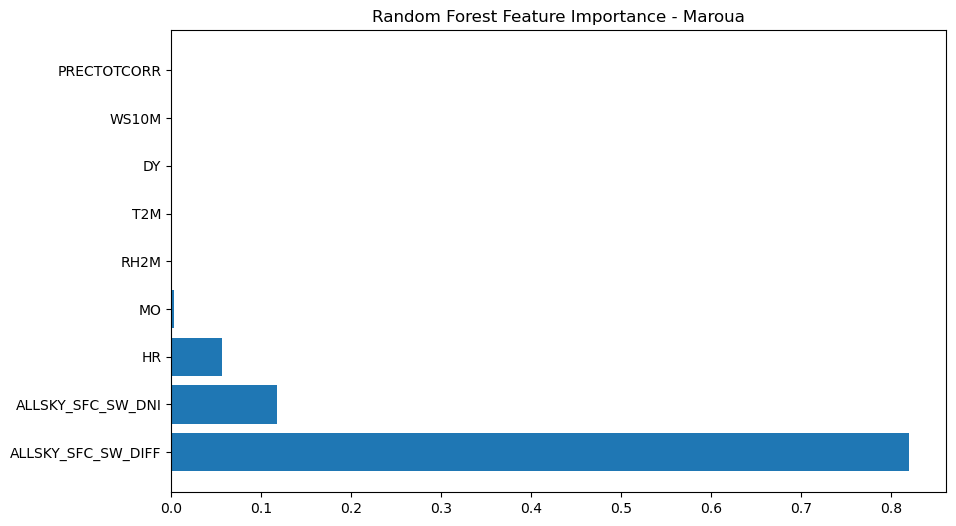

In [ ]:
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("Random Forest Feature Importance - Maroua")
plt.show()

In [ ]:
xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

In [ ]:
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)

rmse_xgb = np.sqrt(
    mean_squared_error(y_test, y_pred_xgb)
)

r2_xgb = r2_score(y_test, y_pred_xgb)

print("XGBoost")
print("MAE =", mae_xgb)
print("RMSE =", rmse_xgb)
print("R² =", r2_xgb)

XGBoost
MAE = 6.881319477974673
RMSE = 15.03292617963903
R² = 0.9978588327998769


In [ ]:
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X)

y_scaled = scaler_y.fit_transform(
    y.values.reshape(-1,1)
)

In [ ]:
def create_sequences(X, y, seq_length):

    Xs = []
    ys = []

    for i in range(len(X) - seq_length):
        Xs.append(X[i:i+seq_length])
        ys.append(y[i+seq_length])

    return np.array(Xs), np.array(ys)

seq_length = 24

X_lstm, y_lstm = create_sequences(
    X_scaled,
    y_scaled,
    seq_length
)

In [ ]:
split_index = int(len(X_lstm) * 0.8)

X_train_lstm = X_lstm[:split_index]
X_test_lstm = X_lstm[split_index:]

y_train_lstm = y_lstm[:split_index]
y_test_lstm = y_lstm[split_index:]

In [ ]:
model = Sequential()

model.add(
    Input(
        shape=(
            X_train_lstm.shape[1],
            X_train_lstm.shape[2]
        )
    )
)

model.add(LSTM(64, activation="relu"))

model.add(Dropout(0.2))

model.add(Dense(32, activation="relu"))

model.add(Dense(1))

model.compile(
    optimizer="adam",
    loss="mse"
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        18,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,057 (82.25 KB)

 Trainable params: 21,057 (82.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train_lstm,
    y_train_lstm,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
1052/1052 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - loss: 0.0078 - val_loss: 0.0022
Epoch 2/20
1052/1052 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 0.0025 - val_loss: 0.0015
Epoch 3/20
1052/1052 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 0.0021 - val_loss: 0.0016
Epoch 4/20
1052/1052 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 0.0018 - val_loss: 0.0013
Epoch 5/20
1052/1052 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 0.0016 - val_loss: 0.0011
Epoch 6/20
1052/1052 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 0.0015 - val_loss: 0.0012
Epoch 7/20
1052/1052 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 0.0014 - val_loss: 9.8310e-04
Epoch 8/20
1052/1052 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - loss: 0.0014 - val_loss: 0.0012
Epoch 9/20
1052/1052 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - loss: 0.0013 - val_loss: 9.6343e-04
Epoch 10/20
1052/1052 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - loss: 0.0013 - val_loss: 0.0010
Epoch 11/20
1052/1052 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - loss: 0.0012 - val_loss: 9.7031e-

In [ ]:
y_pred_lstm = model.predict(X_test_lstm)

y_test_actual = scaler_y.inverse_transform(
    y_test_lstm
)

y_pred_actual = scaler_y.inverse_transform(
    y_pred_lstm
)

mae_lstm = mean_absolute_error(
    y_test_actual,
    y_pred_actual
)

rmse_lstm = np.sqrt(
    mean_squared_error(
        y_test_actual,
        y_pred_actual
    )
)

r2_lstm = r2_score(
    y_test_actual,
    y_pred_actual
)

print("LSTM")
print("MAE =", mae_lstm)
print("RMSE =", rmse_lstm)
print("R² =", r2_lstm)

329/329 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
LSTM
MAE = 13.950891916232777
RMSE = 30.240211202261417
R² = 0.9916899896782411


In [ ]:
results = pd.DataFrame({
    "City": "Maroua",
    "Model": ["Random Forest", "XGBoost", "LSTM"],
    "MAE": [mae_rf, mae_xgb, mae_lstm],
    "RMSE": [rmse_rf, rmse_xgb, rmse_lstm],
    "R2": [r2_rf, r2_xgb, r2_lstm]
})

results.to_csv("results_maroua.csv", index=False)
print(results)

     City          Model        MAE       RMSE        R2
0  Maroua  Random Forest   6.728234  15.079912  0.997845
1  Maroua        XGBoost   6.881319  15.032926  0.997859
2  Maroua           LSTM  13.950892  30.240211  0.991690


In [ ]:
import joblib

joblib.dump(
    xgb,
    "best_maroua_xgb.pkl"
)

print("Maroua model saved successfully")

Maroua model saved successfully
